In [2]:
#Importação das bibliotecas

import pandas       as pd
from sklearn import tree as tr
from sklearn import metrics as mt
from matplotlib import pyplot as plt
from math import sqrt
import numpy as np

In [18]:
#Separação entre treino/ validação / teste

X_train = pd.read_csv('dataset1/X_training (1).csv')
y_train = pd.read_csv('dataset1/y_training (1).csv')
X_test = pd.read_csv('dataset1/X_test (1).csv')
y_test = pd.read_csv('dataset1/y_test (1).csv')
X_validation = pd.read_csv('dataset1/X_validation (1).csv')
y_validation = pd.read_csv('dataset1/y_val.csv')

In [4]:
tree_reg = tr.DecisionTreeRegressor()
tree_reg.fit(X_train,y_train)

yhat_val =tree_reg.predict(X_train)


In [5]:
#Ensaio sobre os dados de treinamento

r2_value = mt.r2_score(y_train, yhat_val)
mse_value = mt.mean_squared_error(y_train,yhat_val)
rmse_value = np.sqrt(mse_value)
mae_value = mt.mean_absolute_error(y_train,yhat_val)
mape_value = mt.mean_absolute_percentage_error(y_train,yhat_val)

print(f"R2 : {r2_value} ")
print(f"MSE : {mse_value} ")
print(f"RMSE : {rmse_value} ")
print(f"MAE : {mae_value} ")
print(f"MAPE : {mape_value} ")

R2 : 0.9917566957405923 
MSE : 3.940402971731975 
RMSE : 1.9850448286454327 
MAE : 0.21409852496986279 
MAPE : 0.08262787375974134 


In [6]:
values = [i for i in range(1,60)]
values_rmse = list()

for i in values:
    tree_reg = tr.DecisionTreeRegressor(max_depth=i)
    tree_reg.fit(X_train, y_train)
    
    yhat_val = tree_reg.predict(X_validation)
    mse = mt.mean_squared_error(y_validation, yhat_val)
    
    values_rmse.append(np.sqrt(mse))

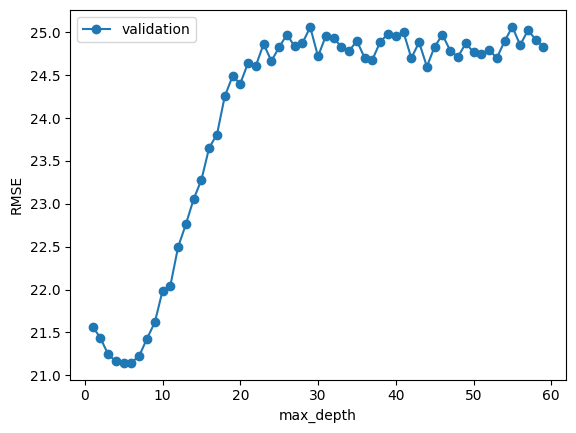

In [7]:
plt.plot(values, values_rmse, '-o', label = 'validation')
plt.xlabel('max_depth')
plt.ylabel('RMSE')
plt.legend()
plt.show()

In [8]:
#melhor max_depth = 4 (mais simples )
tree_reg = tr.DecisionTreeRegressor(max_depth=4)
tree_reg.fit(X_train, y_train)

yhat_val = tree_reg.predict(X_validation)

In [9]:
#Ensaio sobre os dados de validação

r2_value = mt.r2_score(y_validation, yhat_val)
mse_value = mt.mean_squared_error(y_validation,yhat_val)
rmse_value = np.sqrt(mse_value)
mae_value = mt.mean_absolute_error(y_validation,yhat_val)
mape_value = mt.mean_absolute_percentage_error(y_validation,yhat_val)

print(f"R2 : {r2_value} ")
print(f"MSE : {mse_value} ")
print(f"RMSE : {rmse_value} ")
print(f"MAE : {mae_value} ")
print(f"MAPE : {mape_value} ")

R2 : 0.06216761663185344 
MSE : 447.82585312714025 
RMSE : 21.16189625546681 
MAE : 16.849288338389197 
MAPE : 8.536141474557684 


In [ ]:
#Junção dos dados de treinamento com os de validação

tree_reg_last = tr.DecisionTreeRegressor(max_depth= 4)
tree_reg_last.fit( np.concatenate( (X_train, X_validation) ), 
                   np.concatenate((y_train, y_validation)) 
)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_le

In [23]:
#Ensaio sobre os dados de teste
yhat_val = tree_reg_last.predict(X_test.values)

r2_value = mt.r2_score(y_test, yhat_val)
mse_value = mt.mean_squared_error(y_test,yhat_val)
rmse_value = np.sqrt(mse_value)
mae_value = mt.mean_absolute_error(y_test,yhat_val)
mape_value = mt.mean_absolute_percentage_error(y_test,yhat_val)

print(f"R2 : {r2_value} ")
print(f"MSE : {mse_value} ")
print(f"RMSE : {rmse_value} ")
print(f"MAE : {mae_value} ")
print(f"MAPE : {mape_value} ")

R2 : 0.06504830500131586 
MSE : 455.2288927021588 
RMSE : 21.336093660793647 
MAE : 17.033428968872123 
MAPE : 8.129477577701318 
